In this tutorial, I will show you the differences and similarities between [TLS](https://github.com/hippke/tls) and GTLS. Please noticed that GTLS can only run on a computer with a CUDA GPU. And the speed is highly variable depending on your GPU.

This tutorial is adapted from Michael Hippke 's excellent [TLS tutorial](https://github.com/hippke/tls/tree/master/tutorials).

At first, I will use a TESS Target.

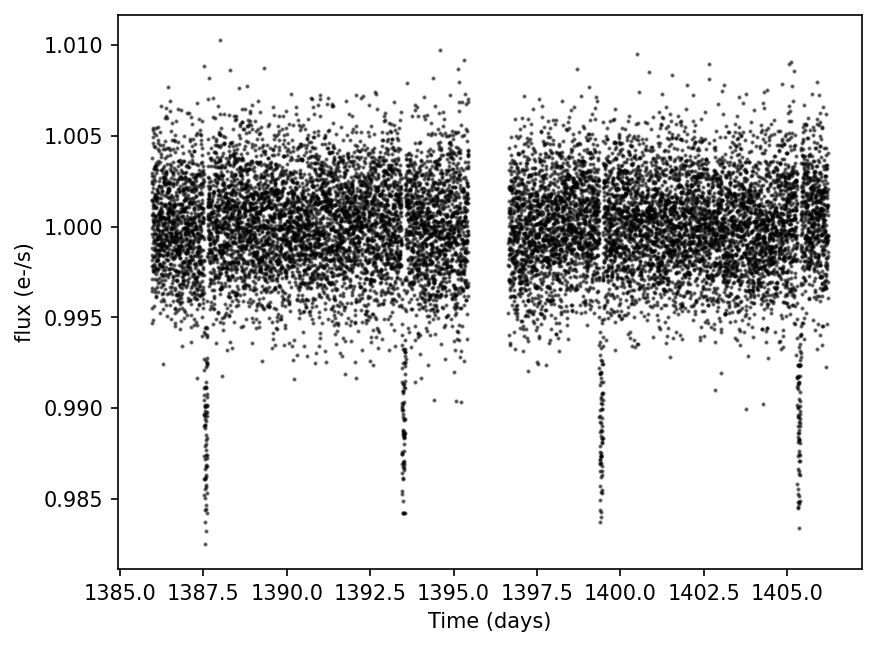

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["figure.dpi"] = 150
import astropy
import numpy
from astropy.io import fits
from astropy.stats import sigma_clip

from transitleastsquares import (
    transitleastsquares,
    cleaned_array,
    catalog_info,
    transit_mask
    )

# We find the URLs of the FITS files on this website:
# https://archive.stsci.edu/prepds/tess-data-alerts/
url = 'https://archive.stsci.edu/hlsps/tess-data-alerts/hlsp_tess-data-alerts_tess_phot_00159951311-s03_tess_v1_lc.fits'
hdu = fits.open(url)
time = hdu[1].data['TIME']
flux = hdu[1].data['PDCSAP_FLUX']  # values with non-zero quality are nan or zero'ed
time, flux = cleaned_array(time, flux)  # remove invalid values such as nan, inf, non, negative
flux = flux / numpy.median(flux)

plt.figure()
plt.xlabel('Time (days)')
plt.ylabel('flux (e-/s)')
plt.scatter(time, flux, color='black', s=1, alpha=0.5);

In [2]:
TIC_ID = hdu[0].header['TICID']
ab, mass, mass_min, mass_max, radius, radius_min, radius_max = catalog_info(TIC_ID=TIC_ID)
print('Searching with limb-darkening estimates using quadratic LD (a,b)=', ab)

Searching with limb-darkening estimates using quadratic LD (a,b)= (0.4136, 0.1999)


In [3]:
import time as Nowtime
TLS_start = Nowtime.time()
model = transitleastsquares(time, flux)
results = model.power()
print('period', results.period, 'duration', results.duration, 'depth', results.depth, 'T0', results.T0,'SDE', results.SDE)
print('TLS took',Nowtime.time() - TLS_start,'seconds')

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 36 durations
Searching 13452 data points, 1744 periods from 0.601 to 10.133 days
Using all 12 CPU threads


100%|██████████| 1744/1744 periods | 00:09<00:00


Searching for best T0 for period 5.92926 days
period 5.929263005077322 duration 0.11744614570380993 depth 0.9887841069182883 T0 1387.564108079596 SDE 14.919208981595345
TLS took 10.403137922286987 seconds


In [4]:
from gputls import gtls
GTLS_start = Nowtime.time()
model = gtls(t = time, y = flux)
gtlsResult = model.power()
print('period', gtlsResult.period, 'duration', gtlsResult.duration, 'depth', gtlsResult.depth, 'T0', gtlsResult.T0,'SDE', gtlsResult.SDE)
print('GTLS took',Nowtime.time() - GTLS_start,'seconds')

GPU Transit Least Squares GTLS 0.2.0 (March 2023)
Creating model cache for 36 durations
Searching 13452 data points, 1744 periods from 0.601 to 10.133 days
gpu memory usage: 4944.12255859375 MB
TotalIter 3
period 5.929263005077322 duration 0.11744614570380993 depth 0.9887841762974858 T0 1387.5656603798627 SDE 14.917344
GTLS took 1.7496058940887451 seconds


: 

As you might see, GTLS basically produces the same results as TLS.

But GTLS is faster than TLS. The sepcific speed is highly variable depending on your GPU.

I use a RTX3060 GPU, a very cheap model for exhibition, and the speed is about 5-6 times faster than my Ryzen R5 3600 CPU.